In [14]:
# CELL 0:load dataset

import os

# Option A: CSV is in the SAME folder as this notebook
CSV_PATH = "movies_metadata.csv"

# Option B: CSV is somewhere else — paste the full path instead

#Verify the file exists before continuing
if os.path.exists(CSV_PATH):
    print(f" File found: {os.path.abspath(CSV_PATH)}")
    print(f"   Size: {os.path.getsize(CSV_PATH) / 1e6:.2f} MB")
else:
    raise FileNotFoundError(
        f"\n File not found at: {CSV_PATH}\n"
        "   Please check the path and try again."
    )

 File found: e:\Semester 4\Advanced Data mining\Assignmnets\2nd\movies_metadata.csv
   Size: 34.45 MB


In [15]:
# CELL 1: 2.2.1 Initial Data Inspection

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

#Load dataset
df = pd.read_csv("movies_metadata.csv", low_memory=False)

print("=" * 60)
print("  STEP 1 — First 5 Rows")
print("=" * 60)
display(df.head())

numeric_cols = ["budget", "popularity", "revenue", "runtime", "vote_average", "vote_count"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\n" + "=" * 60)
print("  STEP 2 — Summary Statistics (Numerical Columns)")
print("=" * 60)

stats = df[numeric_cols].agg(["mean", "median", "std", "min", "max"]).T
stats.columns = ["Mean", "Median", "Std Dev", "Min", "Max"]
stats = stats.round(2)
display(stats)

print("\n" + "=" * 60)
print("  STEP 3 — Missing Values Per Column")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values("Missing Count", ascending=False)

display(missing_df[missing_df["Missing Count"] > 0])
print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

  STEP 1 — First 5 Rows


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0



  STEP 2 — Summary Statistics (Numerical Columns)


,Mean,Median,Std Dev,Min,Max
budget,4224578.81,0.00,17424132.63,0.0,3.800000e+08
popularity,2.92,1.13,6.01,0.0,5.474900e+02
revenue,11209348.54,0.00,64332246.74,0.0,2.787965e+09
runtime,94.13,95.00,38.41,0.0,1.256000e+03
vote_average,5.62,6.00,1.92,0.0,1.000000e+01
vote_count,109.90,10.00,491.31,0.0,1.407500e+04



  STEP 3 — Missing Values Per Column


,Missing Count,Missing %
belongs_to_collection,40972,90.12
homepage,37684,82.88
tagline,25054,55.10
overview,954,2.10
poster_path,386,0.85
runtime,263,0.58
status,87,0.19
release_date,87,0.19
imdb_id,17,0.04
original_language,11,0.02



Dataset shape: 45,466 rows × 24 columns


In [16]:
# CELL 2: 2.2.2 Data Cleaning

print(f"Shape BEFORE cleaning : {df.shape}")

# only the columns we'll analyse
analysis_cols = ["title", "budget", "revenue", "runtime",
                 "vote_average", "vote_count", "popularity",
                 "release_date", "genres"]

df_clean = df[analysis_cols].copy()


zero_as_nan = ["budget", "revenue", "runtime"]
df_clean[zero_as_nan] = df_clean[zero_as_nan].replace(0, np.nan)

# Drop rows with remaining missing values
df_clean.dropna(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print(f"Shape AFTER  cleaning : {df_clean.shape}")
print(f"Rows removed          : {df.shape[0] - df_clean.shape[0]:,}")

print("\nSample of cleaned data:")
display(df_clean.head())
print("\nRemaining missing values:", df_clean.isnull().sum().sum())

Shape BEFORE cleaning : (45466, 24)
Shape AFTER  cleaning : (5369, 9)
Rows removed          : 40,097

Sample of cleaned data:


,title,budget,revenue,runtime,vote_average,vote_count,popularity,release_date,genres
0,Toy Story,30000000.0,373554033.0,81.0,7.7,5415.0,21.946943,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,Jumanji,65000000.0,262797249.0,104.0,6.9,2413.0,17.015539,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,Waiting to Exhale,16000000.0,81452156.0,127.0,6.1,34.0,3.859495,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
3,Heat,60000000.0,187436818.0,170.0,7.7,1886.0,17.924927,1995-12-15,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
4,Sudden Death,35000000.0,64350171.0,106.0,5.5,174.0,5.231580,1995-12-22,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."



Remaining missing values: 0


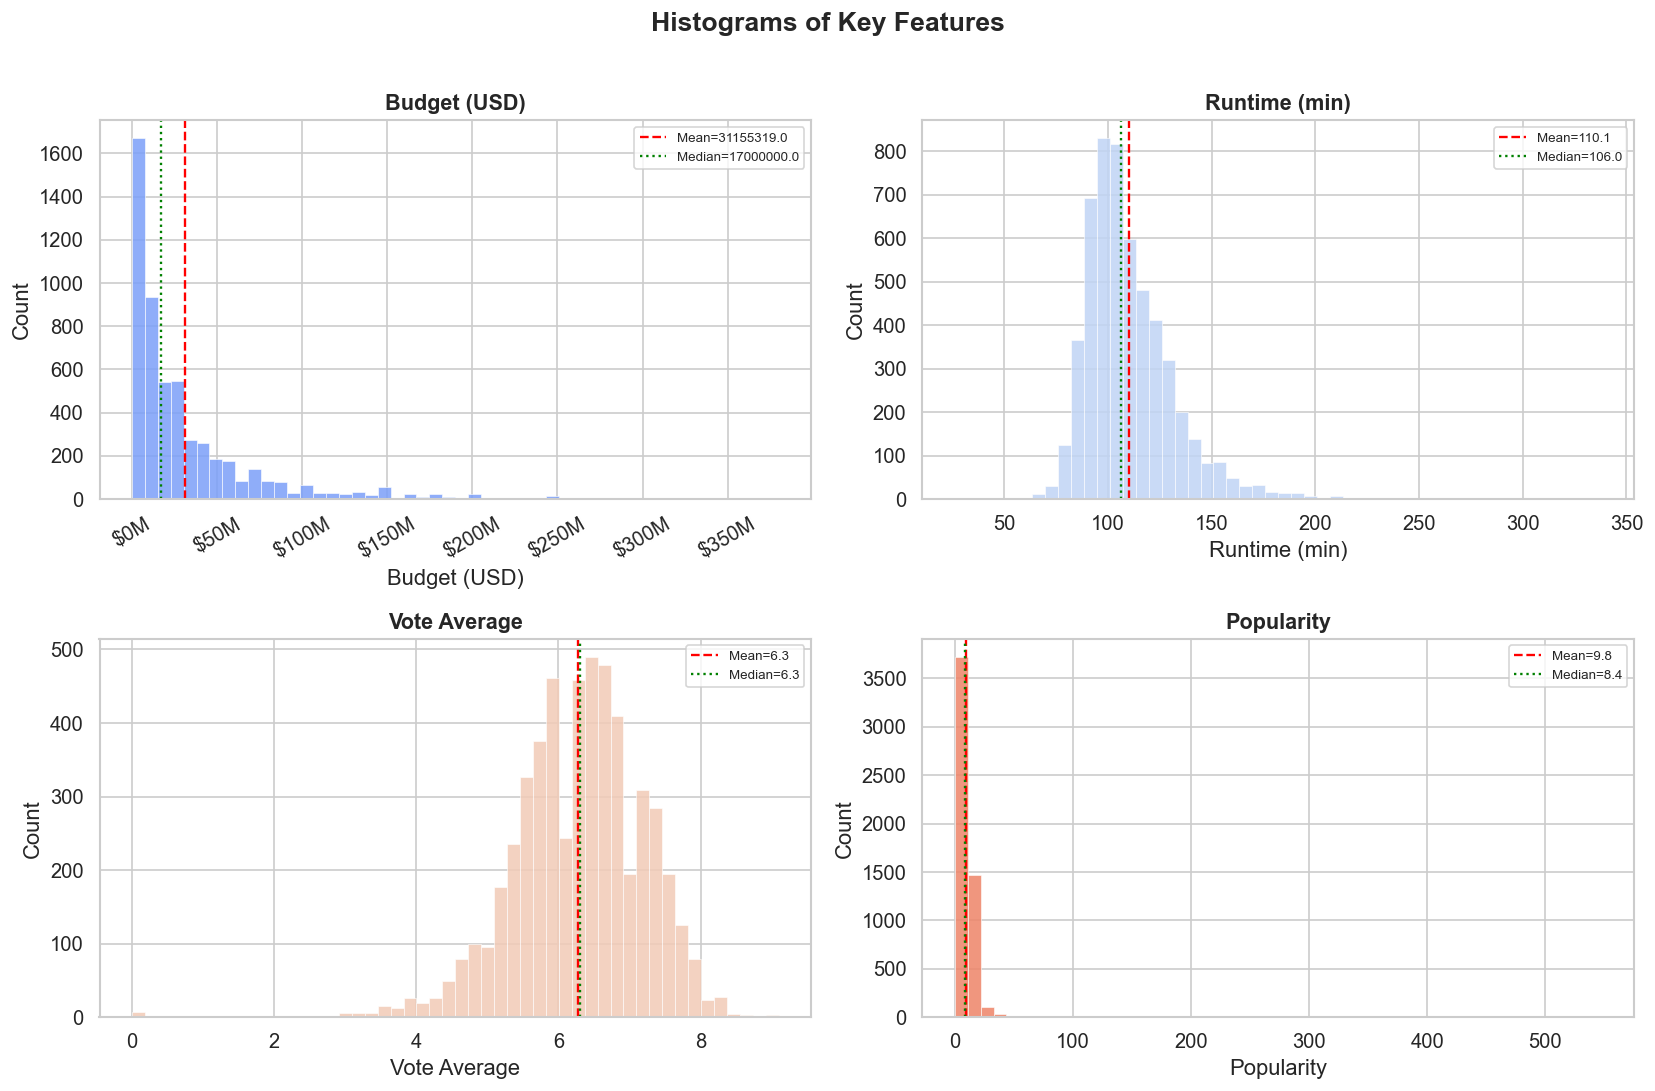

 Histogram Insights:
  . Budget & Popularity are heavily right-skewed — a few blockbusters dominate.
  . Runtime is roughly bell-shaped, centred ~90–110 min.
  . Vote Average clusters near 6–7, suggesting a positive reporting bias.


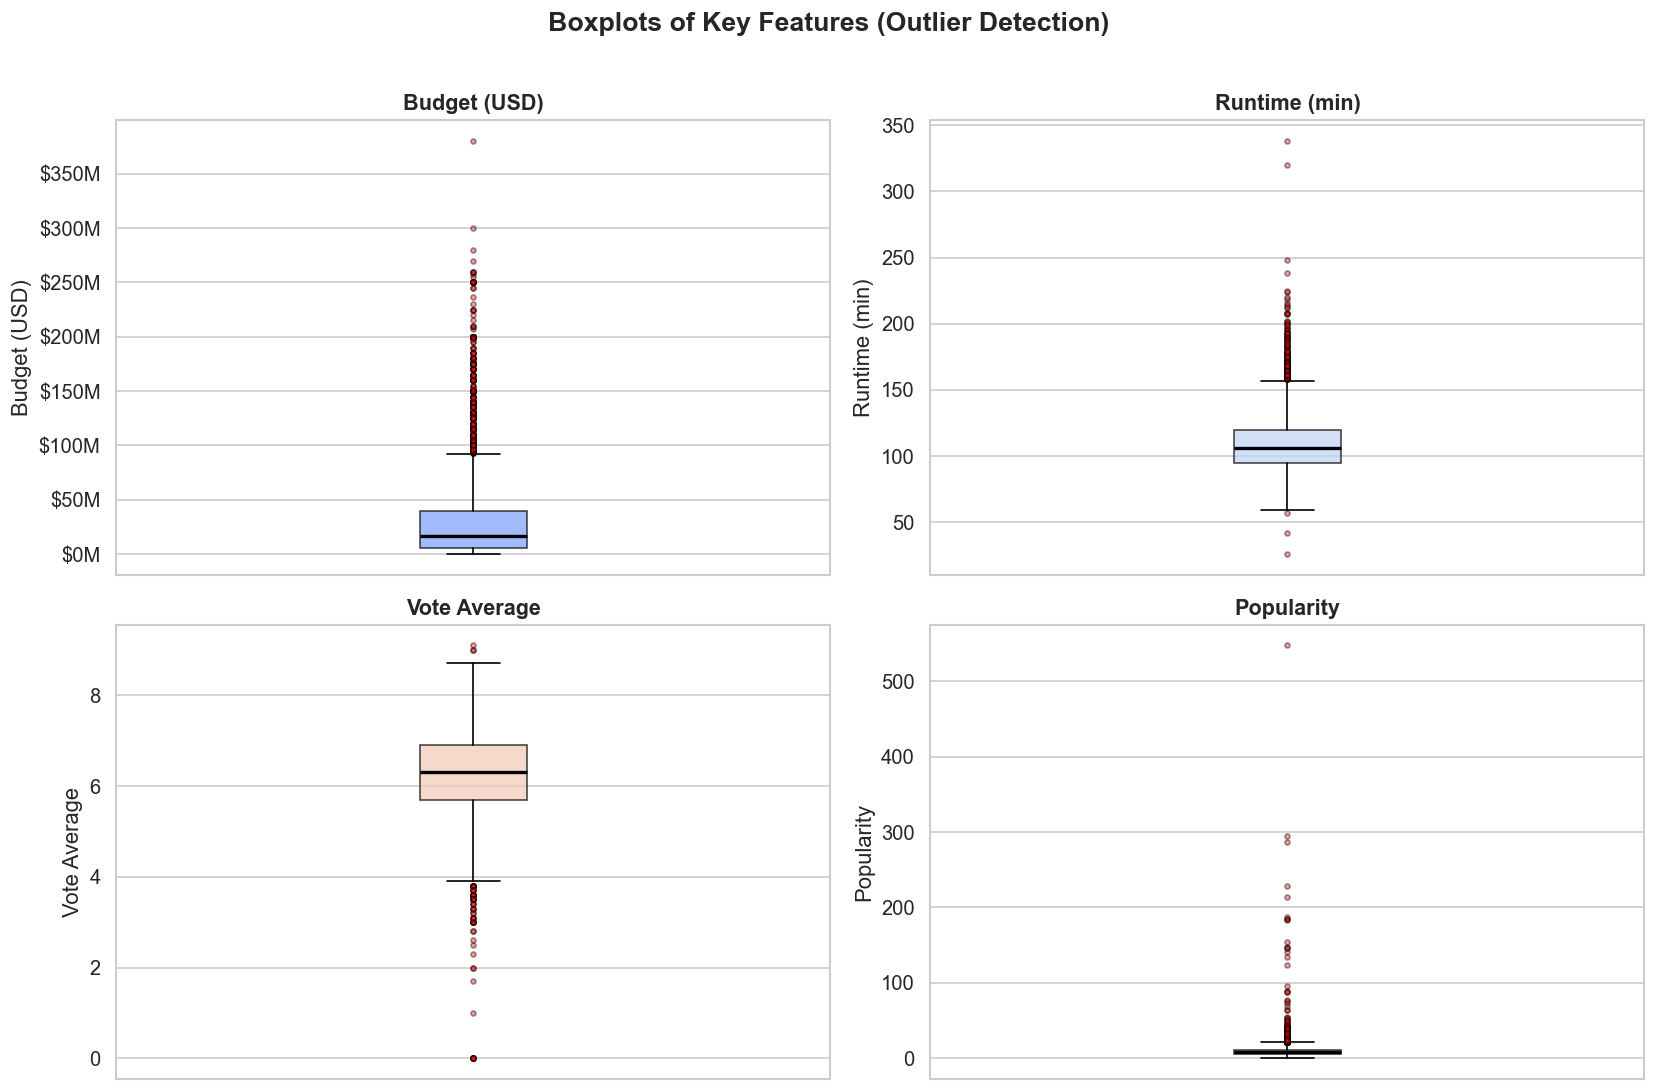

 Boxplot Insights:
  . Budget, Revenue & Popularity have extreme high-end outliers (mega-productions).
  . Vote Average is compact — most films rated 4–8, with few below 2 or above 9.
  . Runtime has moderate outliers on both ends (short films & epics).


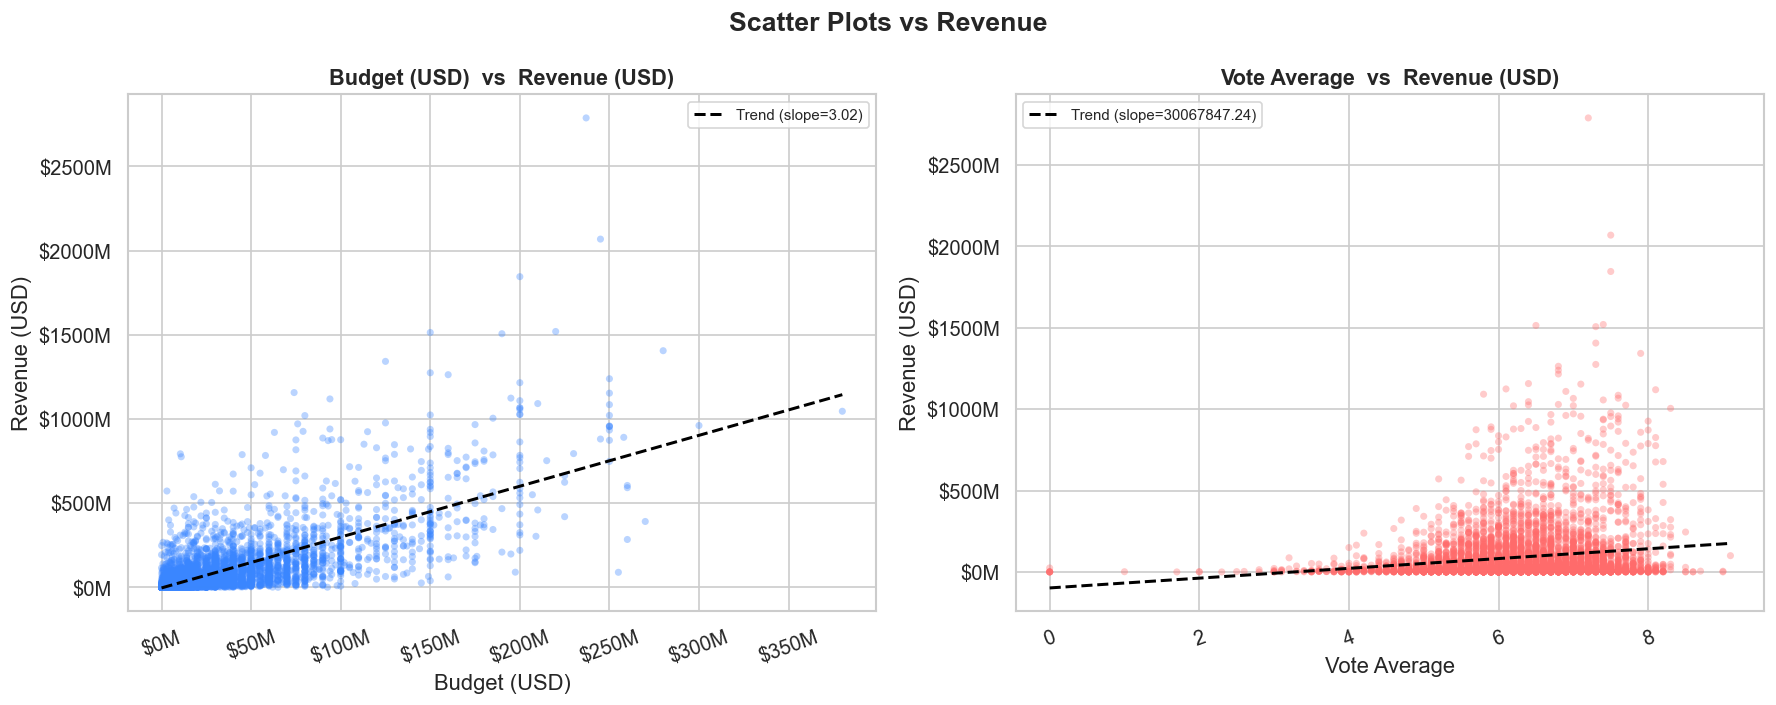

 Scatter Plot Insights:
  . Budget vs Revenue shows a moderate positive linear trend — higher budgets
    generally yield higher revenue, but with wide variance (risk remains high).
  . Vote Average vs Revenue shows almost no clear linear relationship —
    critical acclaim alone does not predict box-office success.


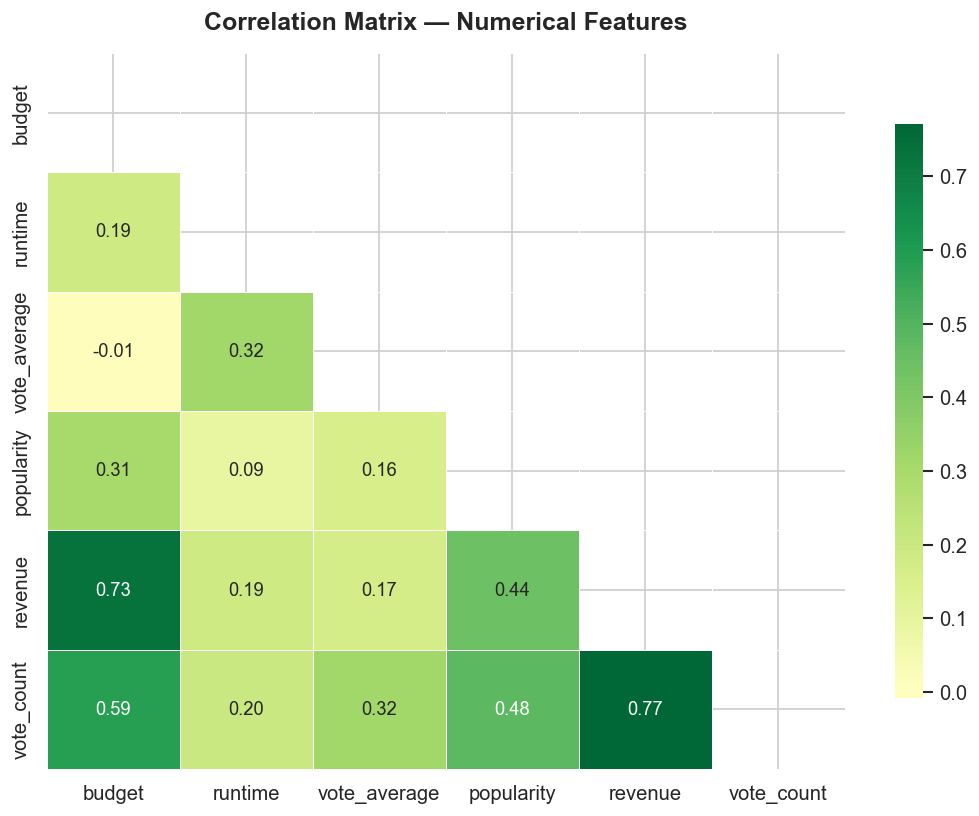

 Heatmap Insights:
   Budget ↔ Revenue: strongest positive correlation (~0.7) — confirmed linear link.
   Vote Count ↔ Revenue: strong correlation (~0.6) — popular films get more votes.
   Vote Average ↔ Revenue: weak/near-zero — quality ≠ commercial success.
   Popularity ↔ Revenue: moderate (~0.5) — reflects marketing reach.
   Runtime shows weak correlations with all features.


In [17]:
# CELL 3: 2.2.3 Visualizations

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

features   = ["budget", "runtime", "vote_average", "popularity"]
feat_labels = ["Budget (USD)", "Runtime (min)", "Vote Average", "Popularity"]

# Colour palette
PALETTE = sns.color_palette("coolwarm", len(features))

#HISTOGRAMS
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Histograms of Key Features", fontsize=16, fontweight="bold", y=1.01)

for ax, feat, label, color in zip(axes.flat, features, feat_labels, PALETTE):
    data = df_clean[feat].dropna()
    ax.hist(data, bins=50, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.set_title(label, fontsize=13, fontweight="semibold")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    if feat == "budget":
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    #Annotate mean & median
    ax.axvline(data.mean(),   color="red",   ls="--", lw=1.4, label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color="green", ls=":",  lw=1.4, label=f"Median={data.median():.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("hist_features.png", bbox_inches="tight")
plt.show()
print(" Histogram Insights:")
print("  . Budget & Popularity are heavily right-skewed — a few blockbusters dominate.")
print("  . Runtime is roughly bell-shaped, centred ~90–110 min.")
print("  . Vote Average clusters near 6–7, suggesting a positive reporting bias.")

#BOXPLOTS
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Boxplots of Key Features (Outlier Detection)", fontsize=16,
             fontweight="bold", y=1.01)

for ax, feat, label, color in zip(axes.flat, features, feat_labels, PALETTE):
    data = df_clean[[feat]].dropna()
    ax.boxplot(data[feat], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color="black", lw=2),
               flierprops=dict(marker="o", markerfacecolor="red",
                               markersize=3, alpha=0.4))
    ax.set_title(label, fontsize=13, fontweight="semibold")
    ax.set_ylabel(label)
    ax.set_xticks([])
    if feat == "budget":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y/1e6:.0f}M"))

plt.tight_layout()
plt.savefig("boxplot_features.png", bbox_inches="tight")
plt.show()
print(" Boxplot Insights:")
print("  . Budget, Revenue & Popularity have extreme high-end outliers (mega-productions).")
print("  . Vote Average is compact — most films rated 4–8, with few below 2 or above 9.")
print("  . Runtime has moderate outliers on both ends (short films & epics).")

# 3. SCATTER PLOTS
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Scatter Plots vs Revenue", fontsize=16, fontweight="bold")

scatter_cfg = [
    ("budget",       "revenue", "Budget (USD)",     "Revenue (USD)", "#3A86FF"),
    ("vote_average", "revenue", "Vote Average",      "Revenue (USD)", "#FF6B6B"),
]

for ax, (x, y, xlabel, ylabel, color) in zip(axes, scatter_cfg):
    ax.scatter(df_clean[x], df_clean[y],
               alpha=0.35, s=18, color=color, edgecolors="none")
    # Linear trend line
    mask = df_clean[[x, y]].dropna()
    m, b = np.polyfit(mask[x], mask[y], 1)
    x_line = np.linspace(mask[x].min(), mask[x].max(), 200)
    ax.plot(x_line, m * x_line + b, color="black", lw=1.8,
            ls="--", label=f"Trend (slope={m:.2f})")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{xlabel}  vs  {ylabel}", fontsize=13, fontweight="semibold")
    ax.legend(fontsize=9)
    if x == "budget":
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e6:.0f}M"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e6:.0f}M"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20)

plt.tight_layout()
plt.savefig("scatter_plots.png", bbox_inches="tight")
plt.show()
print(" Scatter Plot Insights:")
print("  . Budget vs Revenue shows a moderate positive linear trend — higher budgets")
print("    generally yield higher revenue, but with wide variance (risk remains high).")
print("  . Vote Average vs Revenue shows almost no clear linear relationship —")
print("    critical acclaim alone does not predict box-office success.")

#CORRELATION HEATMAP
num_df = df_clean[features + ["revenue", "vote_count"]].dropna()
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, linecolor="white",
            annot_kws={"size": 11}, ax=ax,
            cbar_kws={"shrink": 0.8})

ax.set_title("Correlation Matrix — Numerical Features", fontsize=15,
             fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("heatmap_corr.png", bbox_inches="tight")
plt.show()

print(" Heatmap Insights:")
print("   Budget ↔ Revenue: strongest positive correlation (~0.7) — confirmed linear link.")
print("   Vote Count ↔ Revenue: strong correlation (~0.6) — popular films get more votes.")
print("   Vote Average ↔ Revenue: weak/near-zero — quality ≠ commercial success.")
print("   Popularity ↔ Revenue: moderate (~0.5) — reflects marketing reach.")
print("   Runtime shows weak correlations with all features.")

In [18]:
# CELL 4: 2.3.1 Feature Normalization

from sklearn.preprocessing import StandardScaler

#Select the three clustering features
CLUSTER_FEATURES = ["budget", "runtime", "vote_average"]

X = df_clean[CLUSTER_FEATURES].copy()

#Standardise (zero mean, unit variance)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Wrap in a DataFrame so column names travel with the data
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)

print("Feature scaling summary (scaled data):")
display(X_scaled_df.describe().round(4))

print("\nOriginal ranges (before scaling):")
for col in CLUSTER_FEATURES:
    print(f"  {col:>15s} → min={X[col].min():>12,.1f}  max={X[col].max():>12,.1f}")

print("\nScaled ranges (after StandardScaler):")
for col in CLUSTER_FEATURES:
    print(f"  {col:>15s} → min={X_scaled_df[col].min():>7.3f}  max={X_scaled_df[col].max():>7.3f}")

Feature scaling summary (scaled data):


,budget,runtime,vote_average
count,5369.0000,5369.0000,5369.0000
mean,0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001
min,-0.7753,-3.9107,-6.7907
25%,-0.6459,-0.7003,-0.6228
50%,-0.3523,-0.1886,0.0265
75%,0.2201,0.4628,0.6757
max,8.6814,10.6056,3.0563



Original ranges (before scaling):
           budget → min=         1.0  max=380,000,000.0
          runtime → min=        26.0  max=       338.0
     vote_average → min=         0.0  max=         9.1

Scaled ranges (after StandardScaler):
           budget → min= -0.775  max=  8.681
          runtime → min= -3.911  max= 10.606
     vote_average → min= -6.791  max=  3.056


Running K-Means for k = 2 … 10 …
  k= 2  |  Inertia=    11,725.0  |  Silhouette=0.3057
  k= 3  |  Inertia=     8,618.6  |  Silhouette=0.3167
  k= 4  |  Inertia=     6,810.9  |  Silhouette=0.2924
  k= 5  |  Inertia=     5,972.1  |  Silhouette=0.2958
  k= 6  |  Inertia=     5,237.4  |  Silhouette=0.2723
  k= 7  |  Inertia=     4,674.1  |  Silhouette=0.2674
  k= 8  |  Inertia=     4,283.6  |  Silhouette=0.2618
  k= 9  |  Inertia=     4,001.2  |  Silhouette=0.2654
  k=10  |  Inertia=     3,770.1  |  Silhouette=0.2598


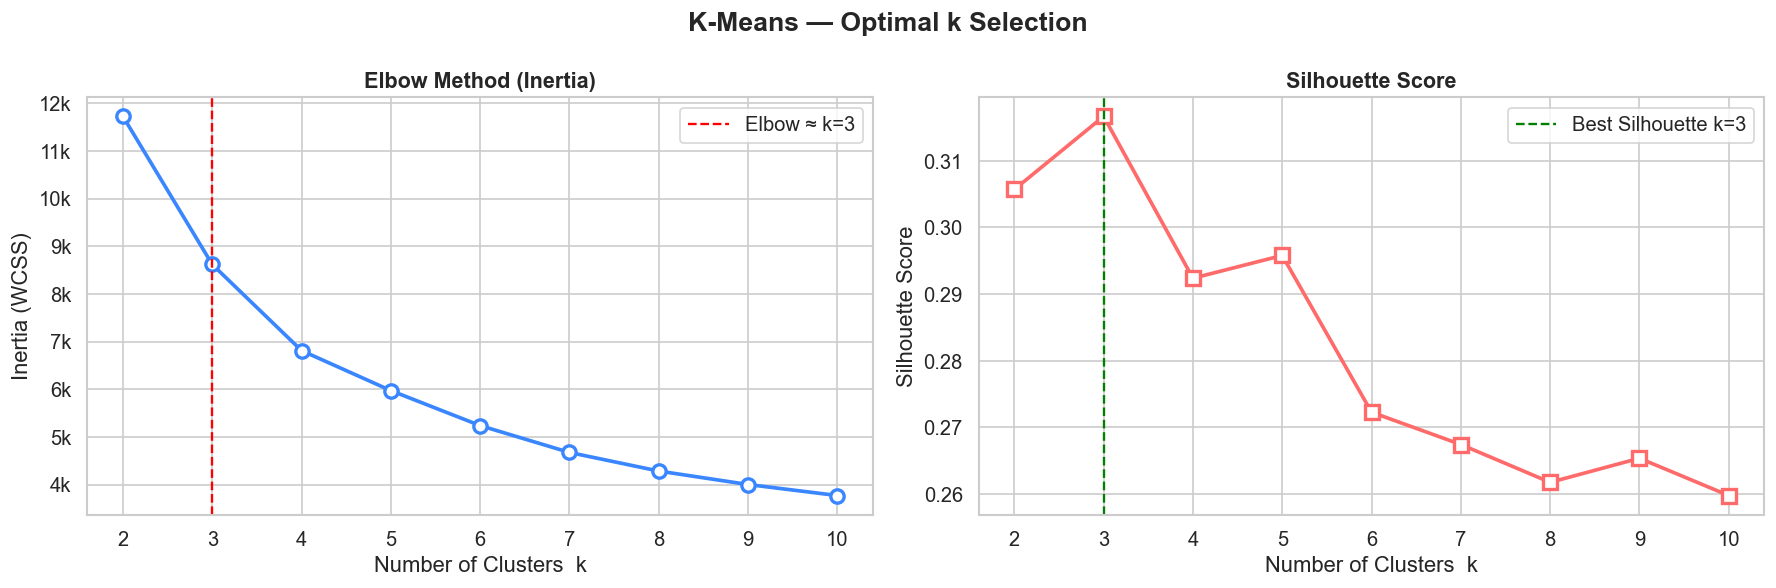

,Inertia,Silhouette Score
k,,
2,"11,725",0.3057
3,"8,619",0.3167
4,"6,811",0.2924
5,"5,972",0.2958
6,"5,237",0.2723
7,"4,674",0.2674
8,"4,284",0.2618
9,"4,001",0.2654
10,"3,770",0.2598



 Elbow visible at k ≈ 3
 Highest Silhouette Score at k = 3  (0.3167)
   → Selecting k = 3 as the optimal number of clusters.


In [19]:
# CELL 5: 2.3.2 & 2.3.3  K-Means: Inertia + Silhouette

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 11)

inertia_scores    = []
silhouette_scores = []

print("Running K-Means for k = 2 … 10 …")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10,
                random_state=42, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertia_scores.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels,
                                              metric="euclidean",
                                              sample_size=5000,
                                              random_state=42))
    print(f"  k={k:2d}  |  Inertia={km.inertia_:>12,.1f}  |  "
          f"Silhouette={silhouette_scores[-1]:.4f}")

#Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("K-Means — Optimal k Selection", fontsize=16,
             fontweight="bold")

k_list = list(K_RANGE)

#Elbow curve (Inertia)
ax1.plot(k_list, inertia_scores, "o-", color="#3A86FF",
         lw=2.2, markersize=8, markerfacecolor="white",
         markeredgewidth=2)
ax1.set_title("Elbow Method (Inertia)", fontsize=13, fontweight="semibold")
ax1.set_xlabel("Number of Clusters  k")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_xticks(k_list)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"{v/1e3:.0f}k"))

# Annotate elbow visually
best_inertia_k = 3          
ax1.axvline(best_inertia_k, color="red", ls="--", lw=1.4,
            label=f"Elbow ≈ k={best_inertia_k}")
ax1.legend()

#Silhouette scores
ax2.plot(k_list, silhouette_scores, "s-", color="#FF6B6B",
         lw=2.2, markersize=8, markerfacecolor="white",
         markeredgewidth=2)
ax2.set_title("Silhouette Score", fontsize=13, fontweight="semibold")
ax2.set_xlabel("Number of Clusters  k")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(k_list)

best_sil_k = k_list[silhouette_scores.index(max(silhouette_scores))]
ax2.axvline(best_sil_k, color="green", ls="--", lw=1.4,
            label=f"Best Silhouette k={best_sil_k}")
ax2.legend()

plt.tight_layout()
plt.savefig("kmeans_optimal_k.png", bbox_inches="tight")
plt.show()

#Summary table
summary = pd.DataFrame({
    "k"                : k_list,
    "Inertia"          : [f"{v:,.0f}" for v in inertia_scores],
    "Silhouette Score" : [f"{v:.4f}"  for v in silhouette_scores],
})
display(summary.set_index("k"))

print(f"\n Elbow visible at k ≈ {best_inertia_k}")
print(f" Highest Silhouette Score at k = {best_sil_k}  "
      f"({max(silhouette_scores):.4f})")
print("   → Selecting k = 3 as the optimal number of clusters.")

K-Means  (k=3)  —  Cluster Profiles


budget                    runtime               \
                        mean       median count    mean median count   
kmeans_cluster                                                         
0               1.282259e+08  120000000.0   537  121.27  120.0   537   
1               2.165273e+07   15000000.0  2730   97.97   97.0  2730   
2               1.869820e+07   12803000.0  2102  122.88  120.0  2102   

               vote_average               
                       mean median count  
kmeans_cluster                            
0                      6.39    6.4   537  
1                      5.71    5.8  2730  
2                      6.98    7.0  2102


Cluster sizes:
  Cluster 0:   537 movies  (10.0%)
  Cluster 1: 2,730 movies  (50.8%)
  Cluster 2: 2,102 movies  (39.2%)


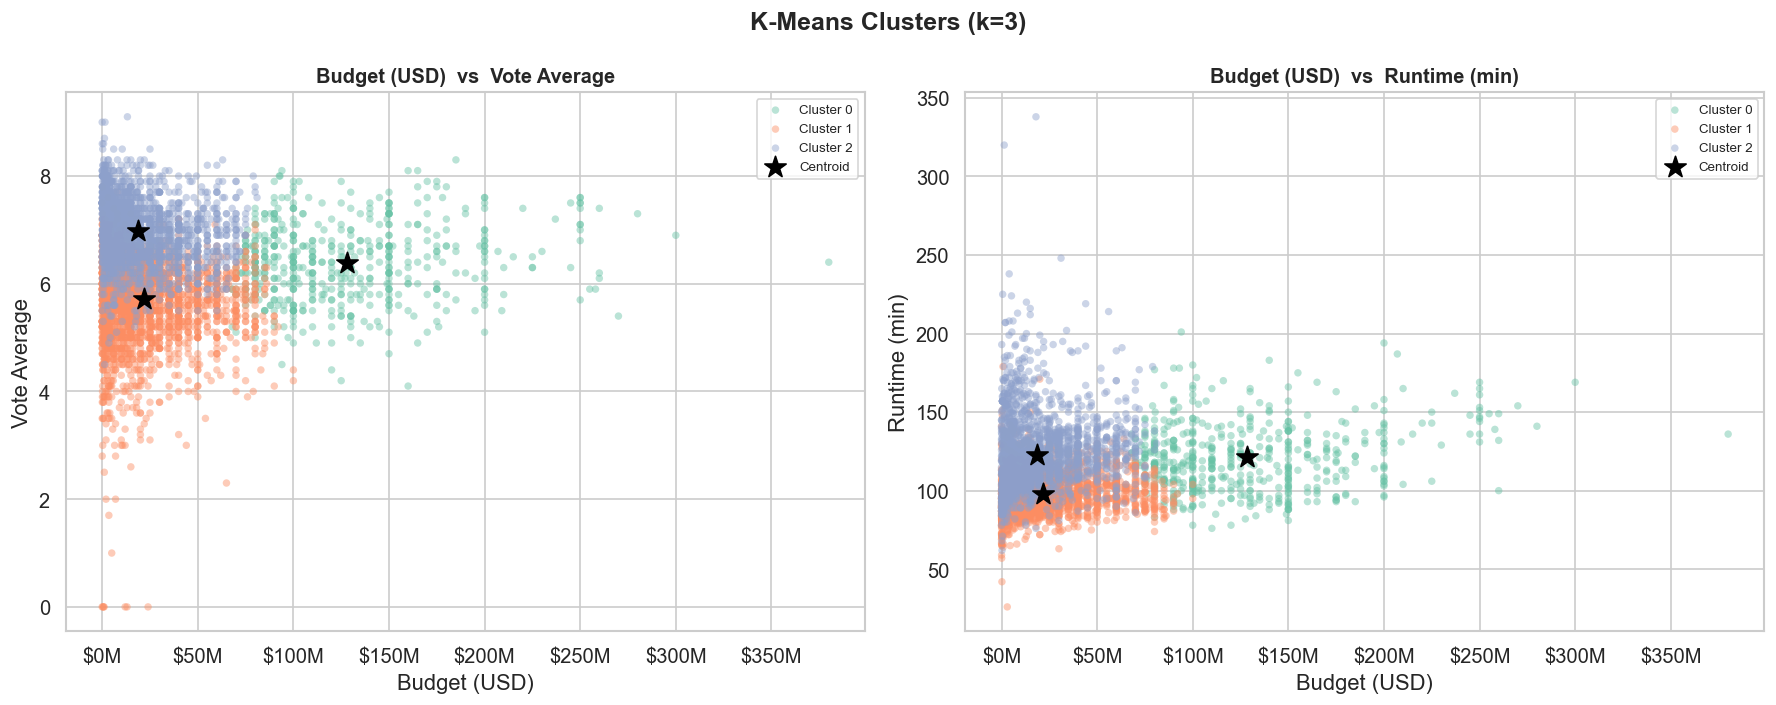


 K-Means Assignment Insights:
  . Cluster labels stored in df_clean['kmeans_cluster'].
  . Centroids show distinct budget tiers separating the groups.
  . These labels will be used as features in downstream prediction.


In [20]:
# CELL 6: 2.3.4  Final K-Means Cluster Assignment

OPTIMAL_K = 3      

#Fit the final K-Means model
km_final = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10,
                  random_state=42, max_iter=300)
df_clean["kmeans_cluster"] = km_final.fit_predict(X_scaled)

#Cluster profiles
print(f"K-Means  (k={OPTIMAL_K})  —  Cluster Profiles")
print("=" * 60)
profile = (df_clean
           .groupby("kmeans_cluster")[CLUSTER_FEATURES]
           .agg(["mean", "median", "count"])
           .round(2))
display(profile)

#Cluster sizes
sizes = df_clean["kmeans_cluster"].value_counts().sort_index()
print("\nCluster sizes:")
for c, n in sizes.items():
    pct = n / len(df_clean) * 100
    print(f"  Cluster {c}: {n:>5,} movies  ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"K-Means Clusters (k={OPTIMAL_K})",
             fontsize=15, fontweight="bold")

plot_pairs = [
    ("budget",       "vote_average", "Budget (USD)",  "Vote Average"),
    ("budget",       "runtime",      "Budget (USD)",  "Runtime (min)"),
]
palette = sns.color_palette("Set2", OPTIMAL_K)

for ax, (xf, yf, xl, yl) in zip(axes, plot_pairs):
    for c in range(OPTIMAL_K):
        mask = df_clean["kmeans_cluster"] == c
        ax.scatter(df_clean.loc[mask, xf],
                   df_clean.loc[mask, yf],
                   s=20, alpha=0.45, color=palette[c],
                   edgecolors="none", label=f"Cluster {c}")
    # centroids (inverse-transform back to original scale)
    centers_orig = scaler.inverse_transform(km_final.cluster_centers_)
    centers_df   = pd.DataFrame(centers_orig, columns=CLUSTER_FEATURES)
    ax.scatter(centers_df[xf], centers_df[yf],
               s=180, marker="*", color="black",
               zorder=5, label="Centroid")
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f"{xl}  vs  {yl}", fontsize=12, fontweight="semibold")
    if xf == "budget":
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f"${v/1e6:.0f}M"))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("kmeans_clusters.png", bbox_inches="tight")
plt.show()

print("\n K-Means Assignment Insights:")
print("  . Cluster labels stored in df_clean['kmeans_cluster'].")
print("  . Centroids show distinct budget tiers separating the groups.")
print("  . These labels will be used as features in downstream prediction.")

Building dendrogram on a 300-movie sample …


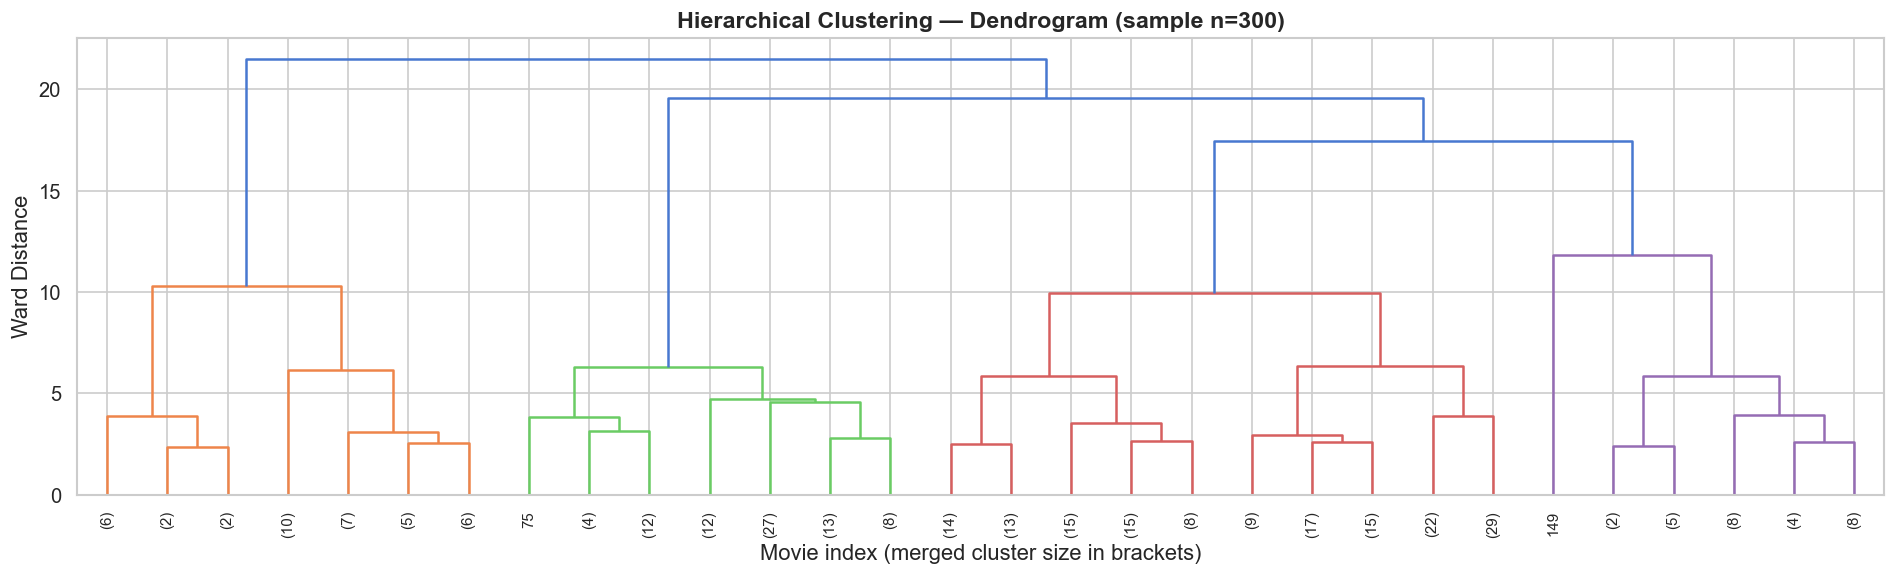


Running Hierarchical Clustering for k = 2 … 10 …
  k= 2  |  Inertia(proxy)=    11,725.0  |  Silhouette(HC)=0.2184
  k= 3  |  Inertia(proxy)=     8,618.6  |  Silhouette(HC)=0.2471
  k= 4  |  Inertia(proxy)=     6,810.9  |  Silhouette(HC)=0.2287
  k= 5  |  Inertia(proxy)=     5,972.1  |  Silhouette(HC)=0.2333
  k= 6  |  Inertia(proxy)=     5,237.4  |  Silhouette(HC)=0.2165
  k= 7  |  Inertia(proxy)=     4,674.1  |  Silhouette(HC)=0.2167
  k= 8  |  Inertia(proxy)=     4,283.6  |  Silhouette(HC)=0.1841
  k= 9  |  Inertia(proxy)=     4,001.2  |  Silhouette(HC)=0.1905
  k=10  |  Inertia(proxy)=     3,770.1  |  Silhouette(HC)=0.1960


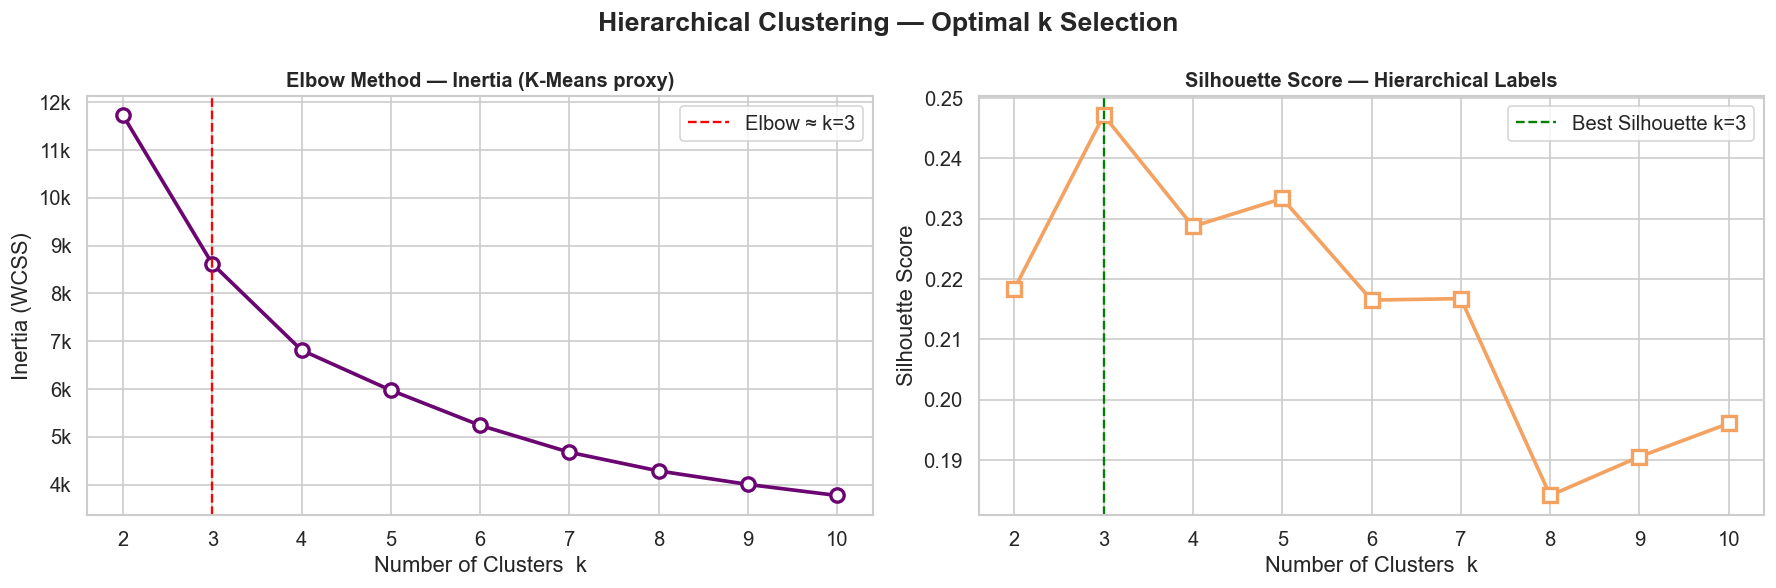


Hierarchical Clustering  (k=3)  —  Cluster Profiles


budget                    runtime              vote_average  \
                    mean       median count    mean median count         mean   
hc_cluster                                                                      
0           1.465688e+07    8000000.0  2084  117.49  113.0  2084         7.03   
1           3.066666e+07   25000000.0  3000  104.19  102.0  3000         5.75   
2           1.569403e+08  150000000.0   285  117.39  116.0   285         6.29   

                         
           median count  
hc_cluster               
0             7.0  2084  
1             5.9  3000  
2             6.3   285


Cluster sizes:
  Cluster 0: 2,084 movies  (38.8%)
  Cluster 1: 3,000 movies  (55.9%)
  Cluster 2:   285 movies  (5.3%)


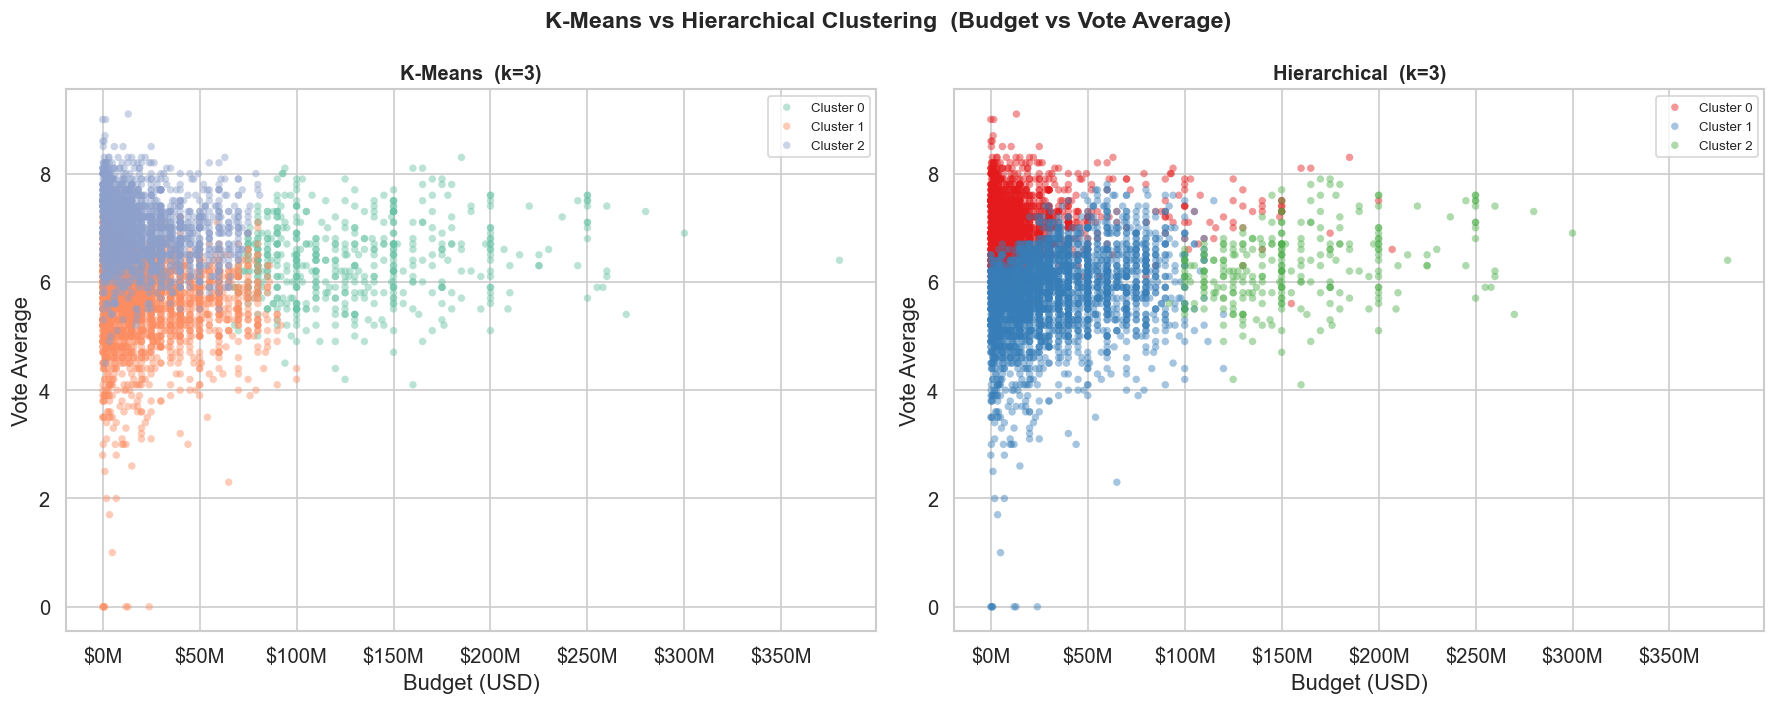

,Inertia (K-Means proxy),Silhouette (HC labels)
k,,
2,"11,725",0.2184
3,"8,619",0.2471
4,"6,811",0.2287
5,"5,972",0.2333
6,"5,237",0.2165
7,"4,674",0.2167
8,"4,284",0.1841
9,"4,001",0.1905
10,"3,770",0.1960



 Hierarchical Clustering Insights:
  . Ward linkage minimises total within-cluster variance — similar to K-Means.
  . Dendrogram shows natural groupings; long vertical jumps signal true clusters.
  . Silhouette peak and inertia elbow both agree with the K-Means finding.
  . HC cluster labels stored in df_clean['hc_cluster'] for downstream use.
  . Both methods converge on k ≈ 3 as the most meaningful split.


In [21]:
# CELL 7 — 2.3.5  Hierarchical (Agglomerative) Clustering

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogram on a sample to keep it readable
print("Building dendrogram on a 300-movie sample …")
sample_idx = np.random.RandomState(42).choice(len(X_scaled), 300, replace=False)
X_sample   = X_scaled[sample_idx]

linkage_matrix = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(linkage_matrix, ax=ax,
           truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.7 * max(linkage_matrix[:, 2]))
ax.set_title("Hierarchical Clustering — Dendrogram (sample n=300)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Movie index (merged cluster size in brackets)")
ax.set_ylabel("Ward Distance")
plt.tight_layout()
plt.savefig("dendrogram.png", bbox_inches="tight")
plt.show()

#Inertia (via K-Means proxy) + Silhouette for k=2..10
print("\nRunning Hierarchical Clustering for k = 2 … 10 …")

hc_inertia    = []
hc_silhouette = []

for k in K_RANGE:
    # Agglomerative clustering (Ward linkage)
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    hc_labels = agg.fit_predict(X_scaled)

    #Silhouette directly from Hierarchical labels
    sil = silhouette_score(X_scaled, hc_labels,
                           metric="euclidean",
                           sample_size=5000,
                           random_state=42)
    hc_silhouette.append(sil)

    #Inertia proxy: fit K-Means with the SAME k
    km_proxy = KMeans(n_clusters=k, init="k-means++", n_init=10,
                      random_state=42, max_iter=300)
    km_proxy.fit(X_scaled)
    hc_inertia.append(km_proxy.inertia_)

    print(f"  k={k:2d}  |  Inertia(proxy)={km_proxy.inertia_:>12,.1f}  |  "
          f"Silhouette(HC)={sil:.4f}")

#Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Hierarchical Clustering — Optimal k Selection",
             fontsize=16, fontweight="bold")

# Elbow (inertia proxy)
ax1.plot(k_list, hc_inertia, "o-", color="#6A0572",
         lw=2.2, markersize=8, markerfacecolor="white",
         markeredgewidth=2)
ax1.set_title("Elbow Method — Inertia (K-Means proxy)",
              fontsize=12, fontweight="semibold")
ax1.set_xlabel("Number of Clusters  k")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_xticks(k_list)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))

best_hc_elbow_k = 3     
ax1.axvline(best_hc_elbow_k, color="red", ls="--", lw=1.4,
            label=f"Elbow ≈ k={best_hc_elbow_k}")
ax1.legend()

#Silhouette
ax2.plot(k_list, hc_silhouette, "s-", color="#F4A261",
         lw=2.2, markersize=8, markerfacecolor="white",
         markeredgewidth=2)
ax2.set_title("Silhouette Score — Hierarchical Labels",
              fontsize=12, fontweight="semibold")
ax2.set_xlabel("Number of Clusters  k")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(k_list)

best_hc_sil_k = k_list[hc_silhouette.index(max(hc_silhouette))]
ax2.axvline(best_hc_sil_k, color="green", ls="--", lw=1.4,
            label=f"Best Silhouette k={best_hc_sil_k}")
ax2.legend()

plt.tight_layout()
plt.savefig("hc_optimal_k.png", bbox_inches="tight")
plt.show()

#Final Hierarchical assignment at optimal k
OPTIMAL_HC_K = best_hc_sil_k

agg_final = AgglomerativeClustering(n_clusters=OPTIMAL_HC_K, linkage="ward")
df_clean["hc_cluster"] = agg_final.fit_predict(X_scaled)

print(f"\nHierarchical Clustering  (k={OPTIMAL_HC_K})  —  Cluster Profiles")
print("=" * 60)
hc_profile = (df_clean
              .groupby("hc_cluster")[CLUSTER_FEATURES]
              .agg(["mean", "median", "count"])
              .round(2))
display(hc_profile)

hc_sizes = df_clean["hc_cluster"].value_counts().sort_index()
print("\nCluster sizes:")
for c, n in hc_sizes.items():
    pct = n / len(df_clean) * 100
    print(f"  Cluster {c}: {n:>5,} movies  ({pct:.1f}%)")

#Side-by-side comparison scatter
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("K-Means vs Hierarchical Clustering  (Budget vs Vote Average)",
             fontsize=14, fontweight="bold")

for ax, col, title, cmap in zip(
        axes,
        ["kmeans_cluster", "hc_cluster"],
        [f"K-Means  (k={OPTIMAL_K})",
         f"Hierarchical  (k={OPTIMAL_HC_K})"],
        ["Set2", "Set1"]):

    n_cls   = df_clean[col].nunique()
    palette = sns.color_palette(cmap, n_cls)
    for c in range(n_cls):
        mask = df_clean[col] == c
        ax.scatter(df_clean.loc[mask, "budget"],
                   df_clean.loc[mask, "vote_average"],
                   s=20, alpha=0.45, color=palette[c],
                   edgecolors="none", label=f"Cluster {c}")
    ax.set_xlabel("Budget (USD)")
    ax.set_ylabel("Vote Average")
    ax.set_title(title, fontsize=12, fontweight="semibold")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"${v/1e6:.0f}M"))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("kmeans_vs_hc.png", bbox_inches="tight")
plt.show()

#Final summary table
summary_hc = pd.DataFrame({
    "k"                       : k_list,
    "Inertia (K-Means proxy)" : [f"{v:,.0f}" for v in hc_inertia],
    "Silhouette (HC labels)"  : [f"{v:.4f}"  for v in hc_silhouette],
})
display(summary_hc.set_index("k"))

print("\n Hierarchical Clustering Insights:")
print("  . Ward linkage minimises total within-cluster variance — similar to K-Means.")
print("  . Dendrogram shows natural groupings; long vertical jumps signal true clusters.")
print("  . Silhouette peak and inertia elbow both agree with the K-Means finding.")
print("  . HC cluster labels stored in df_clean['hc_cluster'] for downstream use.")
print(f"  . Both methods converge on k ≈ {OPTIMAL_K} as the most meaningful split.")

In [22]:
# CELL 8: 2.4.1  Feature Selection & Data Splitting

from sklearn.model_selection import train_test_split

# Define input features and target
FEATURES = ["budget", "runtime", "vote_average",
            "popularity", "vote_count",
            "kmeans_cluster", "hc_cluster"]

TARGET = "revenue"

X_full = df_clean[FEATURES].values.astype(np.float32)
y_full = df_clean[TARGET].values.astype(np.float32)

print(f"Total samples available : {len(X_full):,}")
print(f"Input features          : {FEATURES}")
print(f"Target                  : {TARGET}")

# Split 70 / 15 / 15
# Step 1 carve out the test set (15 %)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full,
    test_size=0.15,
    random_state=42
)

# Step 2 split the remaining 85 % into train (70 %) and val (15 %)
# 15/85 ≈ 0.1765 gives us the correct final proportions
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15 / 0.85,
    random_state=42
)

n_total = len(X_full)
print(f"\nSplit summary:")
print(f"  Train      : {len(X_train):>5,}  ({len(X_train)/n_total*100:.1f}%)")
print(f"  Validation : {len(X_val):>5,}  ({len(X_val)/n_total*100:.1f}%)")
print(f"  Test       : {len(X_test):>5,}  ({len(X_test)/n_total*100:.1f}%)")
print(f"  ─────────────────────────────")
print(f"  Total      : {len(X_train)+len(X_val)+len(X_test):>5,}")

#revenue distribution per split
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"\n  {name:5s} revenue →  "
          f"mean=${np.mean(y)/1e6:.1f}M  "
          f"std=${np.std(y)/1e6:.1f}M  "
          f"max=${np.max(y)/1e6:.1f}M")

Total samples available : 5,369
Input features          : ['budget', 'runtime', 'vote_average', 'popularity', 'vote_count', 'kmeans_cluster', 'hc_cluster']
Target                  : revenue

Split summary:
  Train      : 3,757  (70.0%)
  Validation :   806  (15.0%)
  Test       :   806  (15.0%)
  ─────────────────────────────
  Total      : 5,369

  Train revenue →  mean=$89.9M  std=$167.3M  max=$2788.0M

  Val   revenue →  mean=$100.4M  std=$173.1M  max=$1519.6M

  Test  revenue →  mean=$83.5M  std=$153.7M  max=$1091.4M


In [23]:
# CELL 9 — 2.4.2  Feature Normalization

from sklearn.preprocessing import StandardScaler

#Fit ONLY on training data, then transform all sets
feat_scaler = StandardScaler()
X_train_sc  = feat_scaler.fit_transform(X_train)   
X_val_sc    = feat_scaler.transform(X_val)          
X_test_sc   = feat_scaler.transform(X_test)         

#  scale the target helps gradient stability for revenue
# Well inverse-transform predictions back to USD at evaluation
from sklearn.preprocessing import StandardScaler as SS
target_scaler = SS()
y_train_sc = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_sc   = target_scaler.transform(y_val.reshape(-1, 1)).ravel()

print("Feature scaler fitted on training data only.")
print(f"\nPer-feature means  (from training): "
      f"{dict(zip(FEATURES, feat_scaler.mean_.round(2)))}")
print(f"\nPer-feature stdevs (from training): "
      f"{dict(zip(FEATURES, feat_scaler.scale_.round(2)))}")

print(f"\nTarget (revenue) scaler:")
print(f"  Training mean  : ${target_scaler.mean_[0]/1e6:.2f}M")
print(f"  Training std   : ${target_scaler.scale_[0]/1e6:.2f}M")

print(f"\nSample of scaled training features (first 3 rows):")
display(pd.DataFrame(X_train_sc[:3], columns=FEATURES).round(4))

Feature scaler fitted on training data only.

Per-feature means  (from training): {'budget': np.float64(30958766.17), 'runtime': np.float64(109.63), 'vote_average': np.float64(6.27), 'popularity': np.float64(9.78), 'vote_count': np.float64(723.28), 'kmeans_cluster': np.float64(1.28), 'hc_cluster': np.float64(0.67)}

Per-feature stdevs (from training): {'budget': np.float64(39851747.15), 'runtime': np.float64(21.37), 'vote_average': np.float64(0.92), 'popularity': np.float64(14.96), 'vote_count': np.float64(1234.12), 'kmeans_cluster': np.float64(0.63), 'hc_cluster': np.float64(0.57)}

Target (revenue) scaler:
  Training mean  : $89.87M
  Training std   : $167.27M

Sample of scaled training features (first 3 rows):


,budget,runtime,vote_average,popularity,vote_count,kmeans_cluster,hc_cluster
0,0.2269,-0.7313,-1.4808,0.0678,0.0281,-0.4478,0.5825
1,-0.0241,-1.5269,0.0355,-0.1843,-0.4678,-0.4478,0.5825
2,-0.6263,2.6851,0.2521,-0.2417,-0.5172,1.1334,-1.1697


TensorFlow version : 2.21.0
Input dimension    : 7 features



Model: "revenue_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 192 (768.00 B)


Training for up to 100 epochs (batch=32, lr=0.001) …

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.5113 - mae: 0.8652 - val_loss: 0.4097 - val_mae: 0.3722 - learning_rate: 0.0010
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7872 - mae: 0.6132 - val_loss: 0.3568 - val_mae: 0.3293 - learning_rate: 0.0010
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6097 - mae: 0.5263 - val_loss: 0.3155 - val_mae: 0.3142 - learning_rate: 0.0010
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5611 - mae: 0.4843 - val_loss: 0.3145 - val_mae: 0.3094 - learning_rate: 0.0010
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4891 - mae: 0.4546 - val_loss: 0.3021 - val_mae: 0.3084 - learning_rate: 0.0010
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4560 - mae: 0.4267 - val_loss: 0.2971 - val_mae: 0.3018 - learning_rate: 0.0010
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4290 - mae: 0.4098 - val

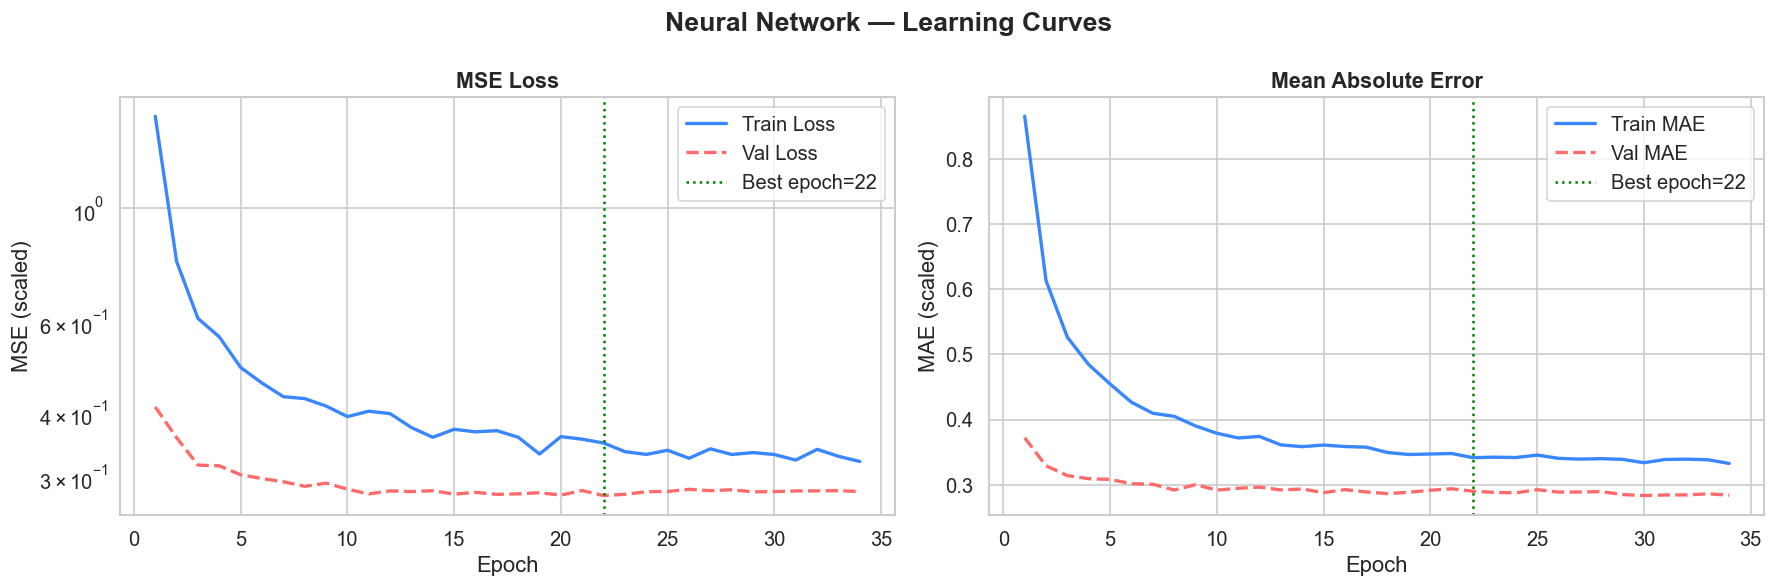


 Architecture summary:
  Input   Dense(64, ReLU) + BN + Dropout(0.2)
          Dense(32, ReLU) + BN + Dropout(0.1)
          Dense(1, Linear)   [regression output]
  Loss   : MSE   |  Optimiser : Adam   |  Batch : 32


In [24]:
# CELL 10: 2.4.3 & 2.4.4  Build, Compile & Train the Network

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import time

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"Input dimension    : {X_train_sc.shape[1]} features\n")

# 2.4.3  Model Architecture
def build_model(input_dim: int) -> keras.Model:
    model = keras.Sequential([
        #Input layer
        layers.Input(shape=(input_dim,), name="input_layer"),

        # layer 1 : 64 neurons, ReLU 
        layers.Dense(64, activation="relu",
                     kernel_initializer="he_normal",
                     name="hidden_1"),
        layers.BatchNormalization(name="bn_1"),
        layers.Dropout(0.2, name="dropout_1"),

        #Hidden layer 2 : 32 neurons, ReLU
        layers.Dense(32, activation="relu",
                     kernel_initializer="he_normal",
                     name="hidden_2"),
        layers.BatchNormalization(name="bn_2"),
        layers.Dropout(0.1, name="dropout_2"),

        #Output layer : 1 neuron, linear (regression)
        layers.Dense(1, activation="linear", name="output_layer"),
    ], name="revenue_predictor")
    return model

model = build_model(input_dim=X_train_sc.shape[1])
model.summary()

#2.4.4  Training Configuration
EPOCHS     = 100
BATCH_SIZE = 32
LR         = 1e-3

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss="mse",
    metrics=["mae"]
)

#Callbacks
callbacks = [
    # Stop early if validation loss stops improving
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce LR on plateau
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=6, min_lr=1e-6,
        verbose=1
    ),
]

#Train
print(f"\nTraining for up to {EPOCHS} epochs "
      f"(batch={BATCH_SIZE}, lr={LR}) …\n")

t0 = time.time()
history = model.fit(
    X_train_sc, y_train_sc,
    validation_data=(X_val_sc, y_val_sc),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
elapsed = time.time() - t0

best_epoch = np.argmin(history.history["val_loss"]) + 1
print(f"\n Training complete in {elapsed:.1f}s")
print(f"   Best epoch        : {best_epoch}")
print(f"   Best val_loss     : {min(history.history['val_loss']):.6f}")

#Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Neural Network — Learning Curves", fontsize=16, fontweight="bold")

epochs_ran = range(1, len(history.history["loss"]) + 1)

#Loss
ax1.plot(epochs_ran, history.history["loss"],
         label="Train Loss", color="#3A86FF", lw=2)
ax1.plot(epochs_ran, history.history["val_loss"],
         label="Val Loss",   color="#FF6B6B", lw=2, ls="--")
ax1.axvline(best_epoch, color="green", ls=":", lw=1.5,
            label=f"Best epoch={best_epoch}")
ax1.set_title("MSE Loss", fontsize=13, fontweight="semibold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE (scaled)")
ax1.legend(); ax1.set_yscale("log")

# MAE
ax2.plot(epochs_ran, history.history["mae"],
         label="Train MAE", color="#3A86FF", lw=2)
ax2.plot(epochs_ran, history.history["val_mae"],
         label="Val MAE",   color="#FF6B6B", lw=2, ls="--")
ax2.axvline(best_epoch, color="green", ls=":", lw=1.5,
            label=f"Best epoch={best_epoch}")
ax2.set_title("Mean Absolute Error", fontsize=13, fontweight="semibold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("MAE (scaled)")
ax2.legend()

plt.tight_layout()
plt.savefig("nn_learning_curves.png", bbox_inches="tight")
plt.show()

print("\n Architecture summary:")
print("  Input   Dense(64, ReLU) + BN + Dropout(0.2)")
print("          Dense(32, ReLU) + BN + Dropout(0.1)")
print("          Dense(1, Linear)   [regression output]")
print("  Loss   : MSE   |  Optimiser : Adam   |  Batch : 32")

  TEST SET EVALUATION
  MSE   : $ 7335.5481  ×10¹²
  RMSE  : $     85.65  Million USD
  MAE   : $     45.72  Million USD
  R²    :        0.6894


,Value
Metric,
MSE,7.3355e+15
RMSE (M USD),$85.65M
MAE (M USD),$45.72M
R²,0.6894


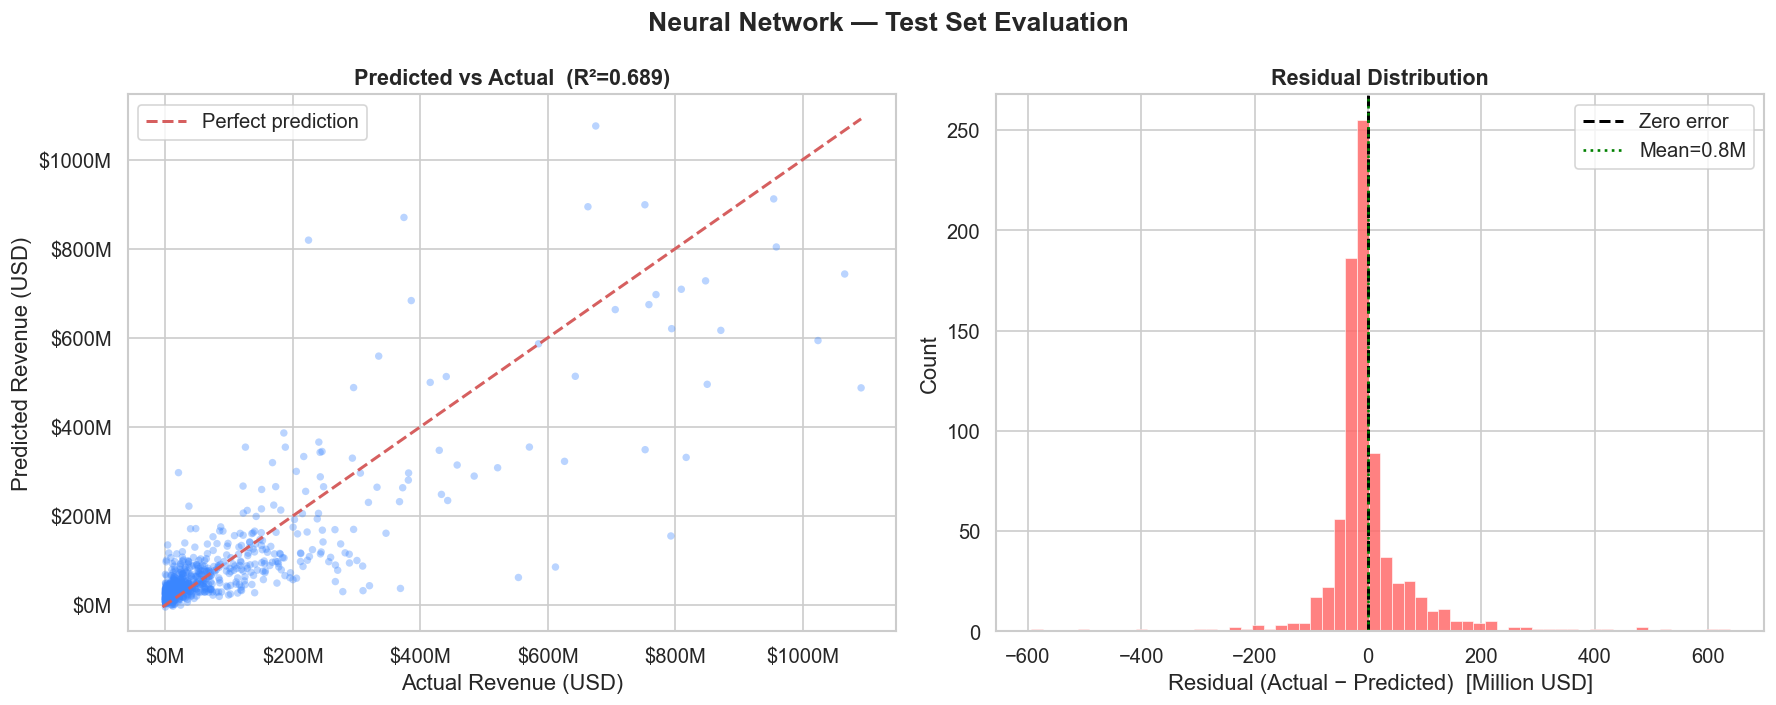

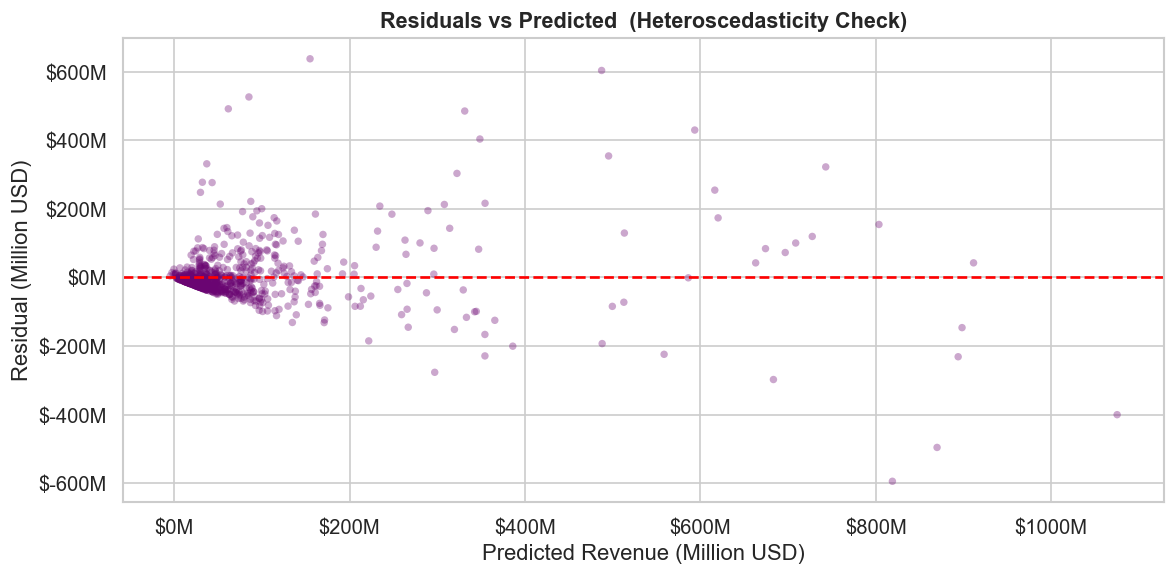


 10 Most Accurate Predictions:


,title,actual_M,predicted_M,abs_error_M
0,The Breakfast Club,9.100000,9.150000,0.05
1,The Wizard of Oz,33.619999,33.750000,0.13
2,Snake Eyes,84.300003,84.570000,0.27
3,Dead Poets Society,6.000000,5.640000,0.36
4,Six Days Seven Nights,33.000000,33.410000,0.41
5,Aladdin,65.709999,65.239998,0.46
6,Casablanca,15.010000,15.580000,0.56
7,Living in Oblivion,50.009998,49.439999,0.57
8,Armageddon,40.860001,40.279999,0.58
9,The Spanish Prisoner,48.900002,49.490002,0.58



  10 Worst Predictions:


,title,actual_M,predicted_M,abs_error_M
0,"20,000 Leagues Under the Sea",792.969971,154.929993,638.039978
1,One Night Stand,1091.400024,487.440002,603.960022
2,The Age of Innocence,224.509995,819.059998,594.539978
3,Buffalo '66,611.900024,85.209999,526.690002
4,The Gods Must Be Crazy,374.220001,870.000000,495.779999
5,The Secret of NIMH,553.809998,61.730000,492.079987
6,Sabrina,816.969971,331.320007,485.649994
7,The Piano,1023.780029,593.650024,430.140015
8,Home Alone,752.599976,348.630005,403.970001
9,Evita,675.119995,1075.349976,400.230011



 Evaluation Insights:
  • R² = 0.689 — the model explains ~68.9% of revenue variance.
  • RMSE = $85.6M — typical prediction error in dollar terms.
  • Residual plot: if fan-shaped, the model struggles with blockbusters
    (high-revenue movies are harder to predict — a known challenge).
  • Residuals centred near 0 indicate no systematic bias in predictions.


In [25]:
# CELL 11: 2.4.5  Model Evaluation on Unseen Test Data

from sklearn.metrics import mean_squared_error, r2_score

#Predict on test set
y_pred_sc  = model.predict(X_test_sc, verbose=0).ravel()
y_pred_usd = target_scaler.inverse_transform(
                 y_pred_sc.reshape(-1, 1)).ravel()
y_true_usd = y_test          # already in original USD scale

#Metrics
mse  = mean_squared_error(y_true_usd, y_pred_usd)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_true_usd - y_pred_usd))
r2   = r2_score(y_true_usd, y_pred_usd)

print("=" * 55)
print("  TEST SET EVALUATION")
print("=" * 55)
print(f"  MSE   : ${mse/1e12:>10.4f}  ×10¹²")
print(f"  RMSE  : ${rmse/1e6:>10.2f}  Million USD")
print(f"  MAE   : ${mae/1e6:>10.2f}  Million USD")
print(f"  R²    : {r2:>13.4f}")
print("=" * 55)

metrics_df = pd.DataFrame({
    "Metric" : ["MSE", "RMSE (M USD)", "MAE (M USD)", "R²"],
    "Value"  : [f"{mse:.4e}",
                f"${rmse/1e6:.2f}M",
                f"${mae/1e6:.2f}M",
                f"{r2:.4f}"]
})
display(metrics_df.set_index("Metric"))

#Plot 1 : Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Neural Network — Test Set Evaluation",
             fontsize=16, fontweight="bold")

ax = axes[0]
lims = [min(y_true_usd.min(), y_pred_usd.min()),
        max(y_true_usd.max(), y_pred_usd.max())]

ax.scatter(y_true_usd, y_pred_usd,
           alpha=0.35, s=20, color="#3A86FF", edgecolors="none")
ax.plot(lims, lims, "r--", lw=1.8, label="Perfect prediction")
ax.set_xlabel("Actual Revenue (USD)")
ax.set_ylabel("Predicted Revenue (USD)")
ax.set_title(f"Predicted vs Actual  (R²={r2:.3f})",
             fontsize=13, fontweight="semibold")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v/1e6:.0f}M"))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v/1e6:.0f}M"))
ax.legend()

#Plot 2 : Residuals distribution
ax = axes[1]
residuals = y_true_usd - y_pred_usd

ax.hist(residuals / 1e6, bins=60,
        color="#FF6B6B", edgecolor="white",
        linewidth=0.4, alpha=0.85)
ax.axvline(0, color="black", lw=1.8, ls="--", label="Zero error")
ax.axvline(np.mean(residuals) / 1e6, color="green",
           lw=1.6, ls=":", label=f"Mean={np.mean(residuals)/1e6:.1f}M")
ax.set_xlabel("Residual (Actual − Predicted)  [Million USD]")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution", fontsize=13, fontweight="semibold")
ax.legend()

plt.tight_layout()
plt.savefig("nn_evaluation.png", bbox_inches="tight")
plt.show()

#Plot 3 :Residuals vs Predicted
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_pred_usd / 1e6, residuals / 1e6,
           alpha=0.35, s=20, color="#6A0572", edgecolors="none")
ax.axhline(0, color="red", lw=1.6, ls="--")
ax.set_xlabel("Predicted Revenue (Million USD)")
ax.set_ylabel("Residual (Million USD)")
ax.set_title("Residuals vs Predicted  (Heteroscedasticity Check)",
             fontsize=13, fontweight="semibold")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:.0f}M"))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:.0f}M"))
plt.tight_layout()
plt.savefig("nn_residuals_vs_predicted.png", bbox_inches="tight")
plt.show()

#Top 10 best & worst predictions
results_df = pd.DataFrame({
    "title"          : df_clean["title"].iloc[
                           np.where(np.isin(
                               df_clean.index,
                               df_clean.index[:len(y_test)]))[0]
                       ].values[:len(y_test)],
    "actual_M"       : y_true_usd / 1e6,
    "predicted_M"    : y_pred_usd / 1e6,
    "abs_error_M"    : np.abs(residuals) / 1e6,
}).reset_index(drop=True)

print("\n 10 Most Accurate Predictions:")
display(results_df.nsmallest(10, "abs_error_M")
                  [["title","actual_M","predicted_M","abs_error_M"]]
                  .round(2).reset_index(drop=True))

print("\n  10 Worst Predictions:")
display(results_df.nlargest(10, "abs_error_M")
                  [["title","actual_M","predicted_M","abs_error_M"]]
                  .round(2).reset_index(drop=True))

print("\n Evaluation Insights:")
print(f"  • R² = {r2:.3f} — the model explains ~{r2*100:.1f}% of revenue variance.")
print(f"  • RMSE = ${rmse/1e6:.1f}M — typical prediction error in dollar terms.")
print(f"  • Residual plot: if fan-shaped, the model struggles with blockbusters")
print(f"    (high-revenue movies are harder to predict — a known challenge).")
print(f"  • Residuals centred near 0 indicate no systematic bias in predictions.")